# Filtros de Sinais
Testar impactos do filtro Butterworth e Notch

## Filtro Butterworth

In [10]:
from scipy.signal import butter, sosfiltfilt

def filtrar_ecg(              # Testar para frequencias mais baixas: 0.1 / 0.05
    sinal, fs=360, freq_baixa=0.5, freq_alta=45.0, ordem=3
):
    """Aplica filtro passa-faixa Butterworth no sinal de ECG.

    - freq_baixa = 0.5 Hz (remove desvio de linha de base / respiracao)
    - freq_alta = 45.0 Hz (remove ruido muscular e rede eletrica de 60 Hz)
    """
    # 1. Frequência de Nyquist (metade da taxa de amostragem)
    nyquist = 0.5 * fs

    # 2. Frequências de corte normalizadas (devem estar entre 0 e 1)
    low = freq_baixa / nyquist
    high = freq_alta / nyquist

    # 3. Calcula os coeficientes b e a do filtro Butterworth
    sos = butter(ordem, [low, high], btype="bandpass", output="sos")

    # 4. Aplica o filtro sem defasagem temporal (fase zero)
    sinal_filtrado = sosfiltfilt(sos, sinal)

    return sinal_filtrado

def butterworth_passa_alta(              
    sinal, fs=360, freq_corte=0.5, ordem=3
):
    """Aplica filtro passa-faixa Butterworth no sinal de ECG.

    - freq_baixa = 0.5 Hz (remove desvio de linha de base / respiracao)
    - freq_alta = 45.0 Hz (remove ruido muscular e rede eletrica de 60 Hz)
    """
    # 1. Frequência de Nyquist (metade da taxa de amostragem)
    nyquist = 0.5 * fs

    # 2. Frequências de corte normalizadas (devem estar entre 0 e 1)
    corte = freq_corte / nyquist

    # 3. Calcula os coeficientes b e a do filtro Butterworth
    sos = butter(ordem, corte, btype="highpass", output="sos")

    # 4. Aplica o filtro sem defasagem temporal (fase zero)
    sinal_filtrado = sosfiltfilt(sos, sinal)

    return sinal_filtrado

def plotar_trecho(trecho_sinal):
    plt.figure(figsize=(10, 4))
    plt.plot(trecho_sinal)

    plt.title("ECG - Puro")
    plt.xlabel("Amostras")
    plt.ylabel("Tensão (mV)")
    plt.show()

In [3]:
import wfdb
record = wfdb.rdrecord('../database/raw/100')
sinal_ecg = record.p_signal
canais = record.sig_name

# Um trecho do sinal de 4 segundos
trecho_sinal = sinal_ecg[:216000, 0]

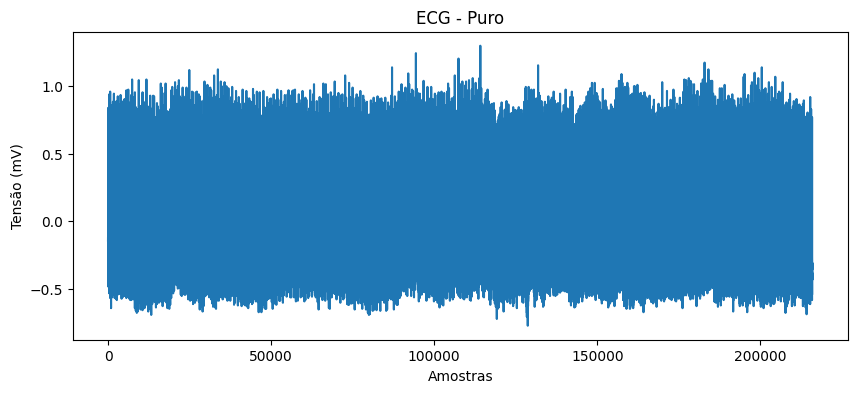

In [102]:
import matplotlib.pyplot as plt

plotar_trecho(trecho_sinal)

In [36]:
import matplotlib.pyplot as plt
import numpy as np


def plotar_fft(sinal_original, sinal_filtrado, nhz_sup=80, nhz_inf=0, y_lim=0.01, fs=360):
    n = len(sinal_original)

    freqs = np.fft.rfftfreq(n, d=1 / fs)

    fft_original = np.abs(np.fft.rfft(sinal_original)) / n
    fft_filtrado = np.abs(np.fft.rfft(sinal_filtrado)) / n

    # Gráfico comparativo
    plt.figure(figsize=(10, 4))
    plt.plot(freqs, fft_original, label="Original", alpha=1)
    plt.plot(freqs, fft_filtrado, label="Filtrado", color="red", alpha=0.6)

    plt.xlim(nhz_inf, nhz_sup)
    plt.ylim(0, y_lim)
    plt.xlabel("Frequência (Hz)")
    plt.ylabel("Magnitude")
    plt.title("Comparação no Domínio da Frequência (FFT)")
    plt.legend()
    plt.grid(True)
    plt.show()

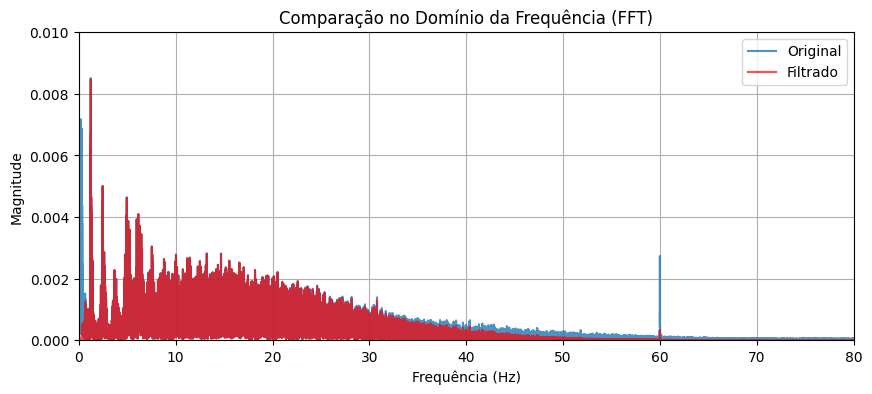

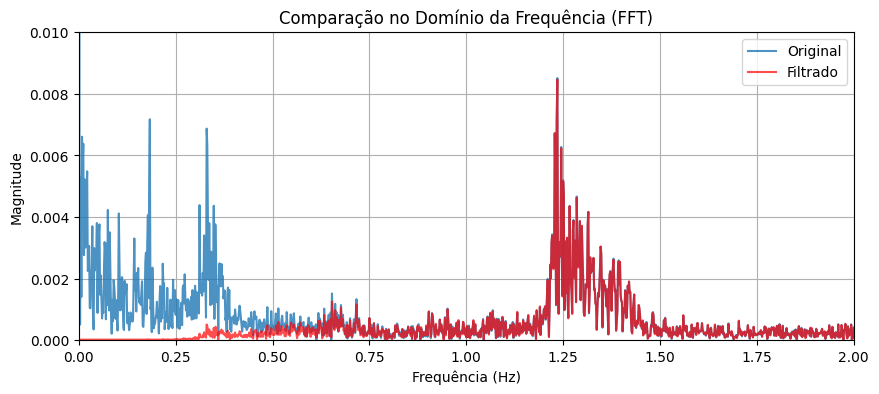

In [104]:
# Base gemini
trecho_sinal_filtrado_1 = filtrar_ecg(trecho_sinal)

plotar_fft(trecho_sinal, trecho_sinal_filtrado_1)
plotar_fft(trecho_sinal, trecho_sinal_filtrado_1, 2)

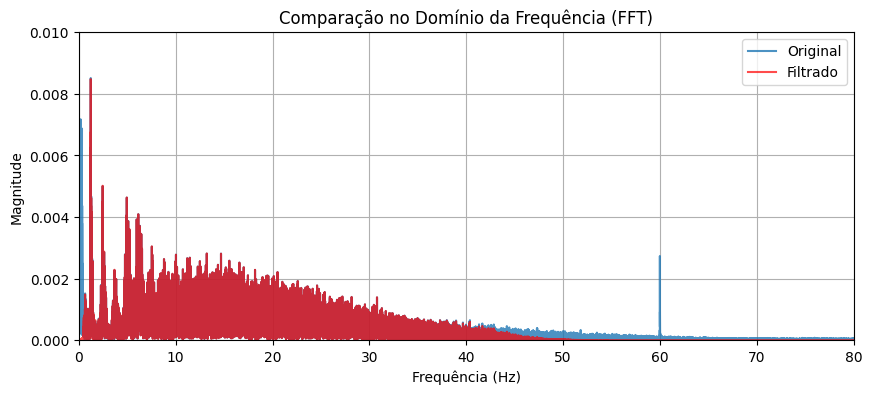

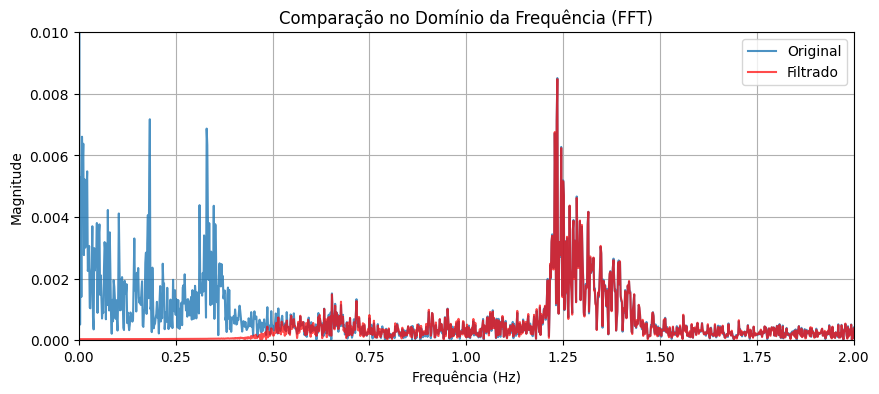

In [108]:
trecho_sinal_filtrado_2 = filtrar_ecg(trecho_sinal, ordem=10)

plotar_fft(trecho_sinal, trecho_sinal_filtrado_2)
plotar_fft(trecho_sinal, trecho_sinal_filtrado_2, 2)

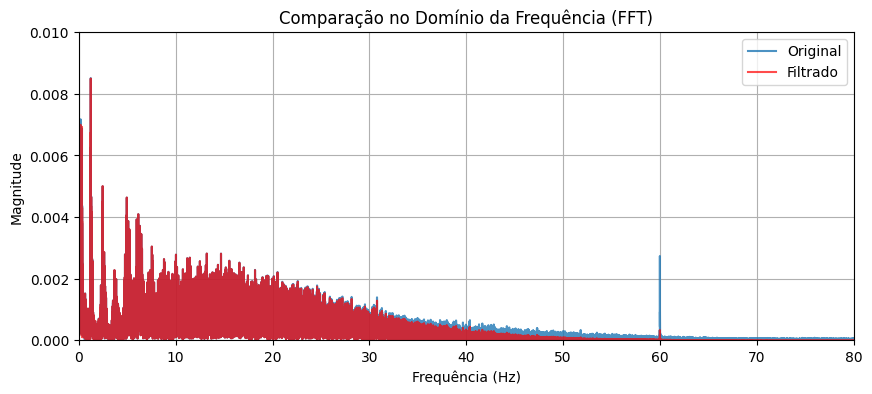

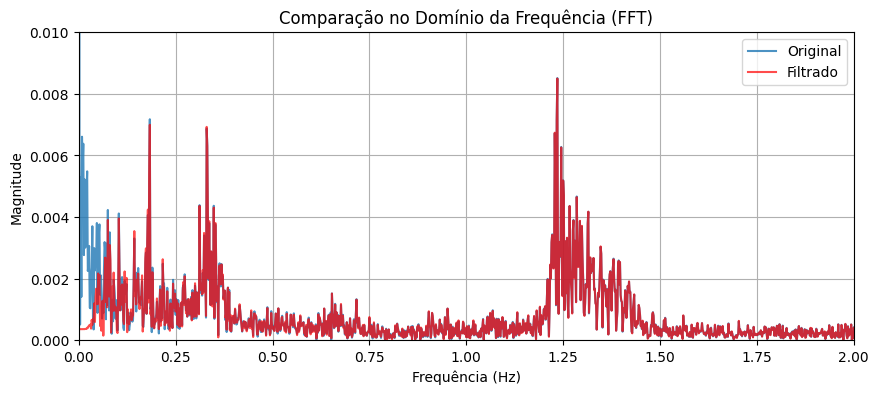

In [109]:
trecho_sinal_filtrado_3 = filtrar_ecg(trecho_sinal, freq_baixa=0.05)

plotar_fft(trecho_sinal, trecho_sinal_filtrado_3)
plotar_fft(trecho_sinal, trecho_sinal_filtrado_3, 2)

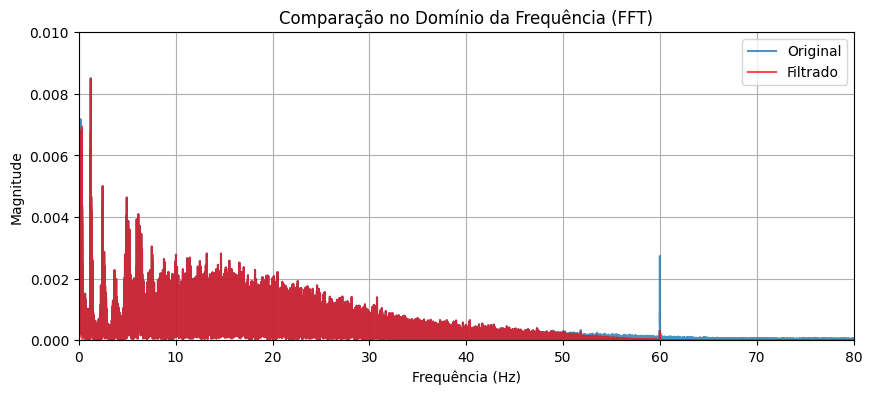

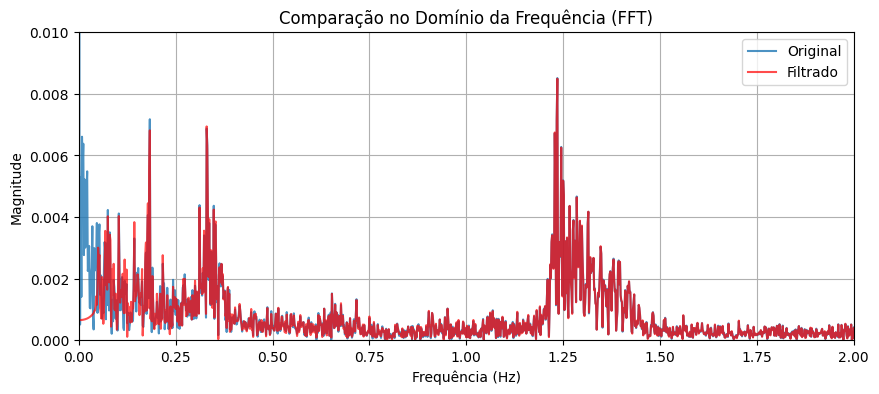

In [155]:
trecho_sinal_filtrado_4 = filtrar_ecg(trecho_sinal, freq_baixa=0.05, freq_alta=55, ordem=10)

plotar_fft(trecho_sinal, trecho_sinal_filtrado_4)
plotar_fft(trecho_sinal, trecho_sinal_filtrado_4, 2)

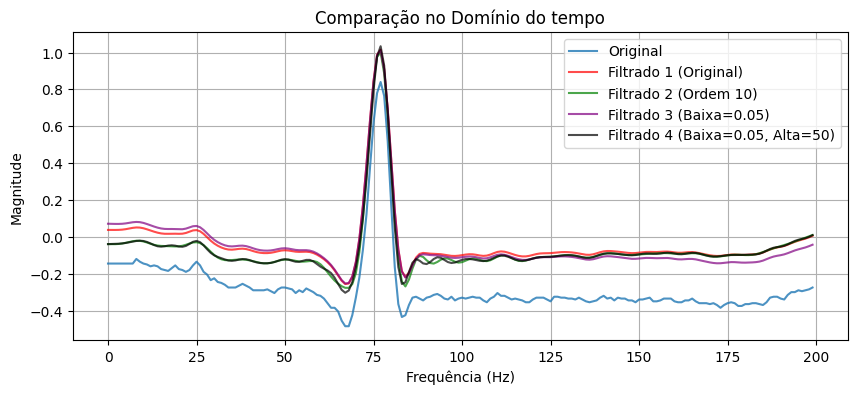

In [154]:
plt.figure(figsize=(10, 4))
plt.plot(trecho_sinal[:200], label="Original", alpha=0.8)
plt.plot(trecho_sinal_filtrado_1[:200], label="Filtrado 1 (Original)", color="red", alpha=0.7)
plt.plot(trecho_sinal_filtrado_2[:200], label="Filtrado 2 (Ordem 10)", color="green", alpha=0.7)
plt.plot(trecho_sinal_filtrado_3[:200], label="Filtrado 3 (Baixa=0.05)", color="purple", alpha=0.7)
plt.plot(trecho_sinal_filtrado_4[:200], label="Filtrado 4 (Baixa=0.05, Alta=50)", color="black", alpha=0.7)

plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude")
plt.title("Comparação no Domínio do tempo")
plt.legend()
plt.grid(True)

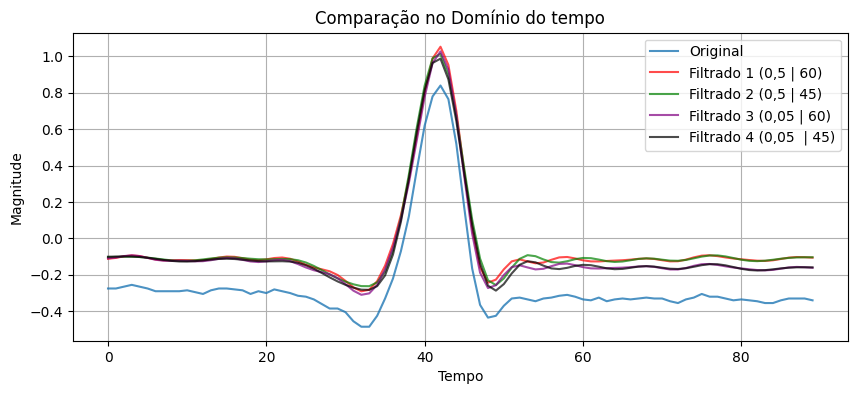

In [173]:
trecho_sinal_filtrado_1 = filtrar_ecg(trecho_sinal, freq_baixa=0.5, freq_alta=60, ordem=9)
trecho_sinal_filtrado_2 = filtrar_ecg(trecho_sinal, freq_baixa=0.5, freq_alta=45, ordem=9)
trecho_sinal_filtrado_3 = filtrar_ecg(trecho_sinal, freq_baixa=0.05, freq_alta=60, ordem=9)
trecho_sinal_filtrado_4 = filtrar_ecg(trecho_sinal, freq_baixa=0.05, freq_alta=45, ordem=9)

plt.figure(figsize=(10, 4))
plt.plot(trecho_sinal[35:125], label="Original", alpha=0.8)
plt.plot(trecho_sinal_filtrado_1[35:125], label="Filtrado 1 (0,5 | 60)", color="red", alpha=0.7)
plt.plot(trecho_sinal_filtrado_2[35:125], label="Filtrado 2 (0,5 | 45)", color="green", alpha=0.7)
plt.plot(trecho_sinal_filtrado_3[35:125], label="Filtrado 3 (0,05 | 60)", color="purple", alpha=0.7)
plt.plot(trecho_sinal_filtrado_4[35:125], label="Filtrado 4 (0,05  | 45)", color="black", alpha=0.7)

plt.xlabel("Tempo")
plt.ylabel("Magnitude")
plt.title("Comparação no Domínio do tempo")
plt.legend()
plt.grid(True)

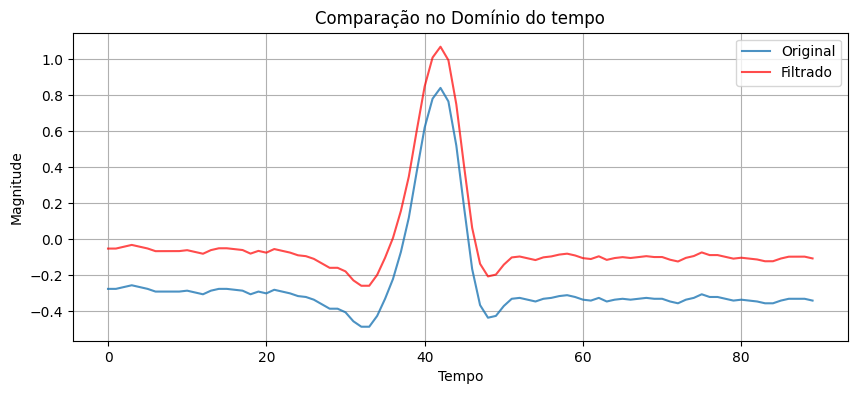

In [102]:
import matplotlib.pyplot as plt

batimento_butterworth_final = butterworth_passa_alta(trecho_sinal, freq_corte=0.1, ordem=3)

plt.figure(figsize=(10, 4))
plt.plot(trecho_sinal[35:125], label="Original", alpha=0.8)
plt.plot(batimento_butterworth_final[35:125], label="Filtrado", color="red", alpha=0.7)

plt.xlabel("Tempo")
plt.ylabel("Magnitude")
plt.title("Comparação no Domínio do tempo")
plt.legend()
plt.grid(True)

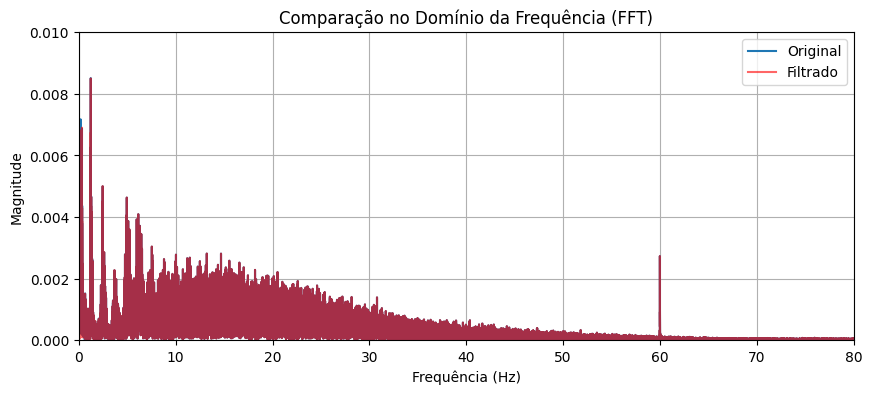

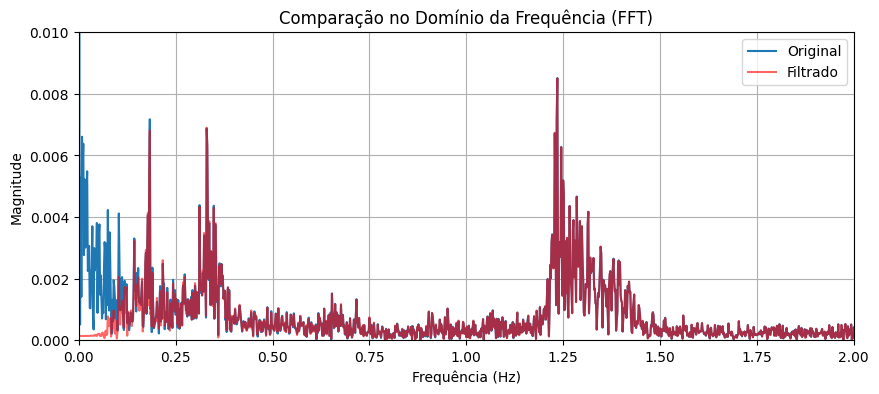

In [103]:
plotar_fft(trecho_sinal, batimento_butterworth_final)
plotar_fft(trecho_sinal, batimento_butterworth_final, 2)

## Filtrar Linha de Energia (60Hz)

In [107]:
from scipy.signal import filtfilt, iirnotch


def filtro_notch(sinal, fs=360, freq_rejeicao=60.0, Q=30.0):
    """Aplica um filtro Notch (rejeita-faixa) IIR no sinal.

    - freq_rejeicao: Frequência central a ser eliminada (ex: 60.0 Hz).
    - Q: Fator de qualidade (largura de banda = freq_rejeicao / Q). Quanto maior
    o Q, mais estreita é a faixa rejeitada (evita atenuar o QRS).
    """
    # 1. Projeta os coeficientes b e a do filtro Notch
    b, a = iirnotch(w0=freq_rejeicao, Q=Q, fs=fs)

    # 2. Aplica o filtro bidirecionalmente (fase zero)
    sinal_filtrado = filtfilt(b, a, sinal)

    return sinal_filtrado

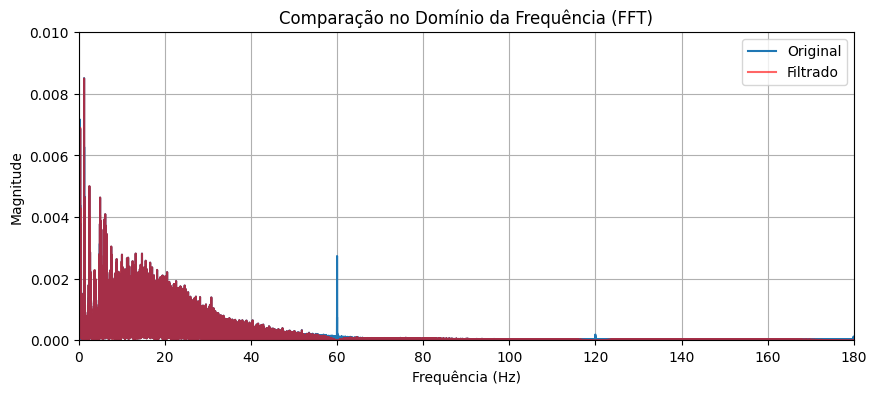

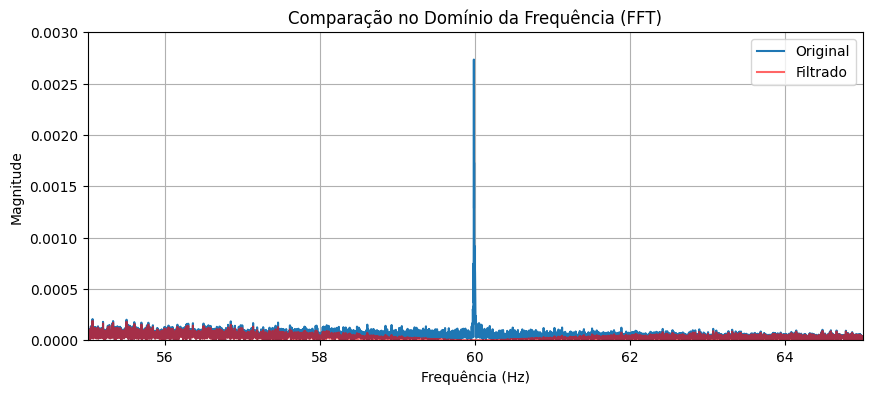

In [108]:
sinal_butterworth_notch_1 = filtro_notch(batimento_butterworth_final, freq_rejeicao=60.0, Q=20.0)
sinal_butterworth_notch_2 = filtro_notch(sinal_butterworth_notch_1, freq_rejeicao=120.0, Q=20.0)
sinal_butterworth_notch_final = filtro_notch(sinal_butterworth_notch_2, freq_rejeicao=180.0, Q=20.0)

plotar_fft(trecho_sinal, sinal_butterworth_notch_final, 180)
plotar_fft(trecho_sinal, sinal_butterworth_notch_final, nhz_inf=55, nhz_sup=65, y_lim=0.003)

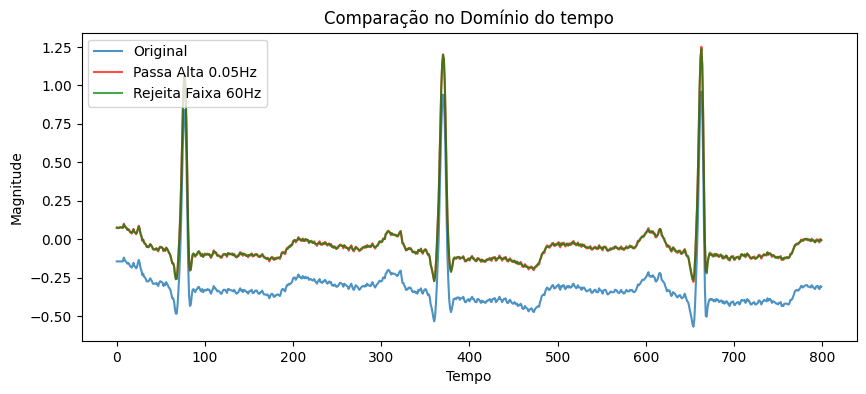

In [109]:
plt.figure(figsize=(10, 4))
plt.plot(trecho_sinal[0:800], label="Original", alpha=0.8)
plt.plot(batimento_butterworth_final[0:800], label="Passa Alta 0.05Hz", color="red", alpha=0.7)
plt.plot(sinal_butterworth_notch_final[0:800], label="Rejeita Faixa 60Hz", color="green", alpha=0.7)

plt.xlabel("Tempo")
plt.ylabel("Magnitude")
plt.title("Comparação no Domínio do tempo")
plt.legend()

## Análise do impacto dos filtros

In [ ]:
# Funções utilizadas

def butterworth_passa_alta(              
    sinal, fs=360, freq_corte=0.05, ordem=3
):
    """Aplica filtro passa-alta Butterworth no sinal de ECG.

    - freq_baixa = 0.05 Hz
    """
    # 1. Frequência de Nyquist (metade da taxa de amostragem)
    nyquist = 0.5 * fs

    # 2. Frequências de corte normalizadas (devem estar entre 0 e 1)
    corte = freq_corte / nyquist

    # 3. Calcula os coeficientes b e a do filtro Butterworth
    sos = butter(ordem, corte, btype="highpass", output="sos")

    # 4. Aplica o filtro sem defasagem temporal (fase zero)
    sinal_filtrado = sosfiltfilt(sos, sinal)

    return sinal_filtrado

def filtro_notch(sinal, fs=360, freq_rejeicao=60.0, Q=10.0):
    """Aplica um filtro Notch (rejeita-faixa) IIR no sinal.

    - freq_rejeicao: Frequência central a ser eliminada (ex: 60.0 Hz).
    - Q: Fator de qualidade (largura de banda = freq_rejeicao / Q). Quanto maior
    o Q, mais estreita é a faixa rejeitada (evita atenuar o QRS).
    """
    # 1. Projeta os coeficientes b e a do filtro Notch
    b, a = iirnotch(w0=freq_rejeicao, Q=Q, fs=fs)

    # 2. Aplica o filtro bidirecionalmente (fase zero)
    sinal_filtrado = filtfilt(b, a, sinal)

    return sinal_filtrado

In [79]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import (
    butter,
    freqz,
    iirnotch,
    sos2zpk,
    sosfreqz,
    tf2zpk,
)  # Garanta a importação de butter


# ==============================================================================
# 1. ANÁLISE DO FILTRO BUTTERWORTH PASSA-ALTAS (COM AJUSTE FILTFILT)
# ==============================================================================
def analisar_butterworth_passa_alta(
    fs=360, freq_corte=0.05, ordem=9, xlim=(0, 2)
):
    """Gera o diagrama de polos/zeros e resposta em frequência considerando a

    filtragem bidirecional de fase zero (sosfiltfilt).
    """
    nyquist = 0.5 * fs
    corte = freq_corte / nyquist
    sos = butter(ordem, corte, btype="highpass", output="sos")

    # Polos, zeros e resposta em frequência do filtro base
    z, p, k = sos2zpk(sos)
    w, h = sosfreqz(sos, worN=4096, fs=fs)

    # AJUSTE FILTFILT: Magnitude ao quadrado -> |H(f)|^2 (o dobro em dB)
    mag_db_filtfilt = 40 * np.log10(np.abs(h) + 1e-12)
    fase_filtfilt = np.zeros_like(w)  # Fase é cancelada (fase zero)

    fig = plt.figure(figsize=(13, 5))

    # --- Diagrama de Polos e Zeros (Plano Z) ---
    ax1 = fig.add_subplot(1, 2, 1)
    theta = np.linspace(0, 2 * np.pi, 300)
    ax1.plot(
        np.cos(theta),
        np.sin(theta),
        "k--",
        alpha=0.6,
        label="Círculo Unitário (|z|=1)",
    )
    ax1.axhline(0, color="gray", linestyle=":", alpha=0.5)
    ax1.axvline(0, color="gray", linestyle=":", alpha=0.5)

    ax1.scatter(
        np.real(z),
        np.imag(z),
        s=80,
        facecolors="none",
        edgecolors="blue",
        marker="o",
        linewidths=2,
        label=f"Zeros ({len(z)})",
    )
    ax1.scatter(
        np.real(p),
        np.imag(p),
        s=80,
        color="red",
        marker="x",
        linewidths=2,
        label=f"Polos ({len(p)})",
    )

    ax1.set_title(
        f"Polos e Zeros - Butterworth Passa-Altas\n($f_c = {freq_corte}$ Hz, Ordem = {ordem})",
        fontweight="bold",
    )
    ax1.set_xlabel(r"Parte Real ($\Re\{z\}$)")
    ax1.set_ylabel(r"Parte Imaginária ($\Im\{z\}$)")
    ax1.set_xlim(-1.2, 1.2)
    ax1.set_ylim(-1.2, 1.2)
    ax1.set_aspect("equal", "box")
    ax1.legend(loc="upper right")
    ax1.grid(True, linestyle="--", alpha=0.5)

    # --- Resposta em Magnitude Efetiva (dB) ---
    ax2 = fig.add_subplot(2, 2, 2)
    ax2.plot(w, mag_db_filtfilt, "b", lw=1.8)
    ax2.set_title(
        "Resposta em Magnitude Efetiva ($|H(f)|^2$ - sosfiltfilt)",
        fontweight="bold",
    )
    ax2.set_ylabel("Magnitude (dB)")
    ax2.set_xlim(xlim)
    ax2.grid(True, linestyle="--", alpha=0.5)

    # --- Resposta em Fase Efetiva (Graus) ---
    ax3 = fig.add_subplot(2, 2, 4)
    ax3.plot(w, fase_filtfilt, "g", lw=1.8)
    ax3.set_title(
        "Resposta em Fase Efetiva (Fase Zero)", fontweight="bold"
    )
    ax3.set_xlabel("Frequência (Hz)")
    ax3.set_ylabel("Fase (graus)")
    ax3.set_ylim(-10, 10)
    ax3.set_xlim(xlim)
    ax3.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()


# ==============================================================================
# 2. ANÁLISE DO FILTRO NOTCH (60 Hz - COM AJUSTE FILTFILT)
# ==============================================================================
def analisar_filtro_notch(fs=360, freq_rejeicao=60.0, Q=10.0, xlim=(45, 75)):
    """Gera o diagrama de polos/zeros e resposta em frequência considerando a

    filtragem bidirecional de fase zero (filtfilt).
    """
    b, a = iirnotch(w0=freq_rejeicao, Q=Q, fs=fs)

    # Polos, zeros e resposta em frequência do filtro base
    z, p, k = tf2zpk(b, a)
    w, h = freqz(b, a, worN=4096, fs=fs)

    # AJUSTE FILTFILT: Magnitude ao quadrado -> |H(f)|^2 (o dobro em dB)
    mag_db_filtfilt = 40 * np.log10(np.abs(h) + 1e-12)
    fase_filtfilt = np.zeros_like(w)  # Fase é cancelada (fase zero)

    fig = plt.figure(figsize=(13, 5))

    # --- Diagrama de Polos e Zeros (Plano Z) ---
    ax1 = fig.add_subplot(1, 2, 1)
    theta = np.linspace(0, 2 * np.pi, 300)
    ax1.plot(
        np.cos(theta),
        np.sin(theta),
        "k--",
        alpha=0.6,
        label="Círculo Unitário (|z|=1)",
    )
    ax1.axhline(0, color="gray", linestyle=":", alpha=0.5)
    ax1.axvline(0, color="gray", linestyle=":", alpha=0.5)

    ax1.scatter(
        np.real(z),
        np.imag(z),
        s=80,
        facecolors="none",
        edgecolors="blue",
        marker="o",
        linewidths=2,
        label=f"Zeros ({len(z)})",
    )
    ax1.scatter(
        np.real(p),
        np.imag(p),
        s=80,
        color="red",
        marker="x",
        linewidths=2,
        label=f"Polos ({len(p)})",
    )

    ax1.set_title(
        f"Polos e Zeros - Filtro Notch\n($f_0 = {freq_rejeicao}$ Hz, Q = {Q})",
        fontweight="bold",
    )
    ax1.set_xlabel(r"Parte Real ($\Re\{z\}$)")
    ax1.set_ylabel(r"Parte Imaginária ($\Im\{z\}$)")
    ax1.set_xlim(-1.2, 1.2)
    ax1.set_ylim(-1.2, 1.2)
    ax1.set_aspect("equal", "box")
    ax1.legend(loc="upper right")
    ax1.grid(True, linestyle="--", alpha=0.5)

    # --- Resposta em Magnitude Efetiva (dB) ---
    ax2 = fig.add_subplot(2, 2, 2)
    ax2.plot(w, mag_db_filtfilt, "b", lw=1.8)
    ax2.set_title(
        "Resposta em Magnitude Efetiva ($|H(f)|^2$ - filtfilt)",
        fontweight="bold",
    )
    ax2.set_ylabel("Magnitude (dB)")
    ax2.set_xlim(xlim)
    ax2.grid(True, linestyle="--", alpha=0.5)

    # --- Resposta em Fase Efetiva (Graus) ---
    ax3 = fig.add_subplot(2, 2, 4)
    ax3.plot(w, fase_filtfilt, "g", lw=1.8)
    ax3.set_title(
        "Resposta em Fase Efetiva (Fase Zero)", fontweight="bold"
    )
    ax3.set_xlabel("Frequência (Hz)")
    ax3.set_ylabel("Fase (graus)")
    ax3.set_ylim(-10, 10)
    ax3.set_xlim(xlim)
    ax3.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

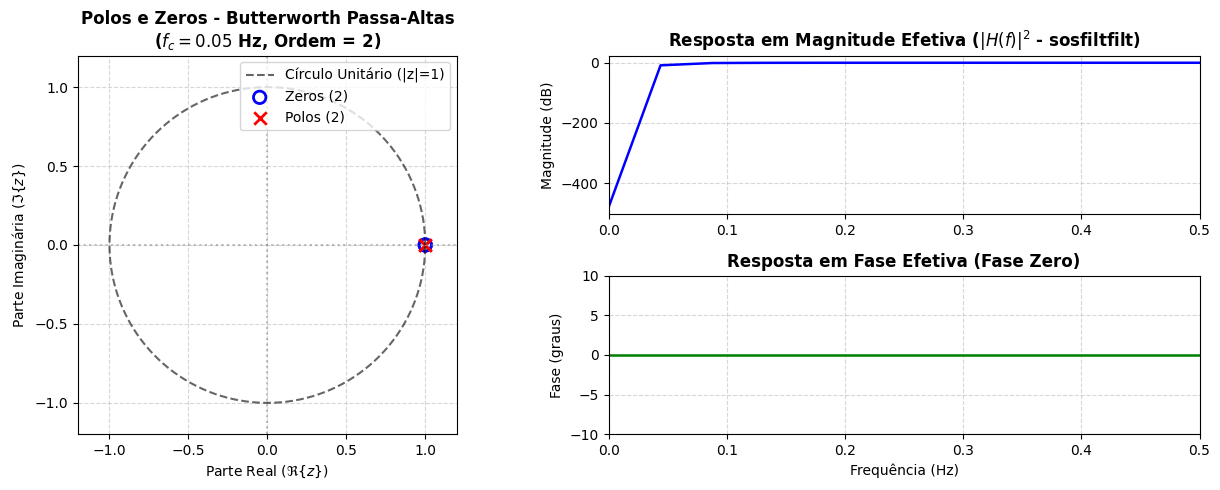

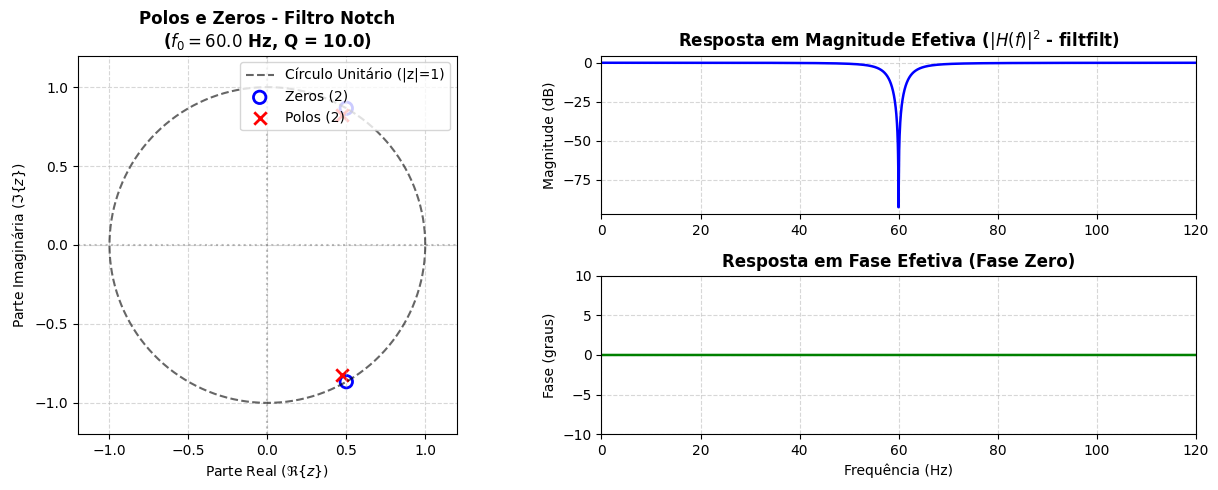

In [86]:
analisar_butterworth_passa_alta(fs=360, freq_corte=0.05, ordem=2, xlim=(0, 0.5))
analisar_filtro_notch(fs=360, freq_rejeicao=60.0, Q=10.0, xlim=(0, 120))

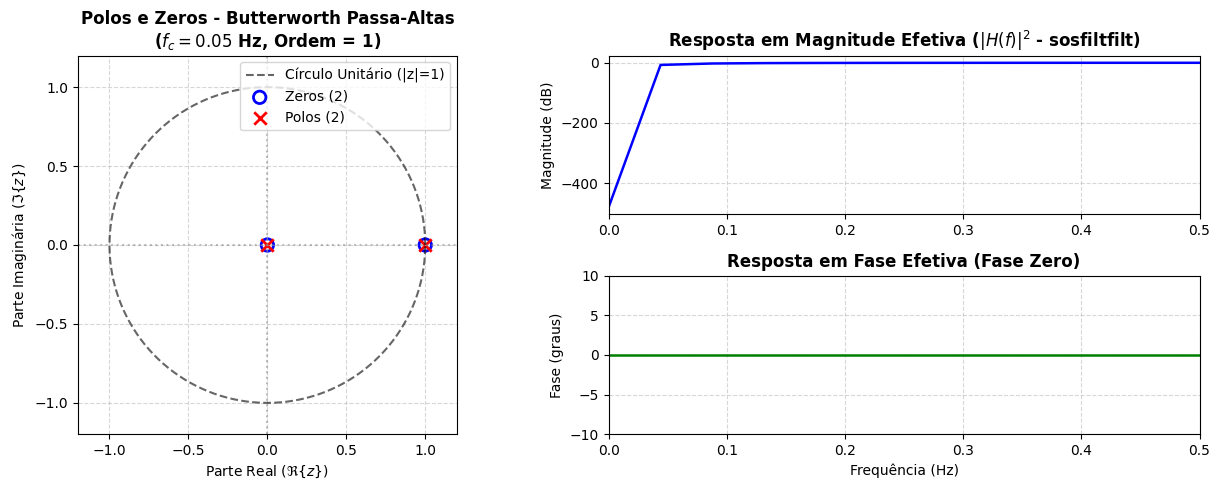

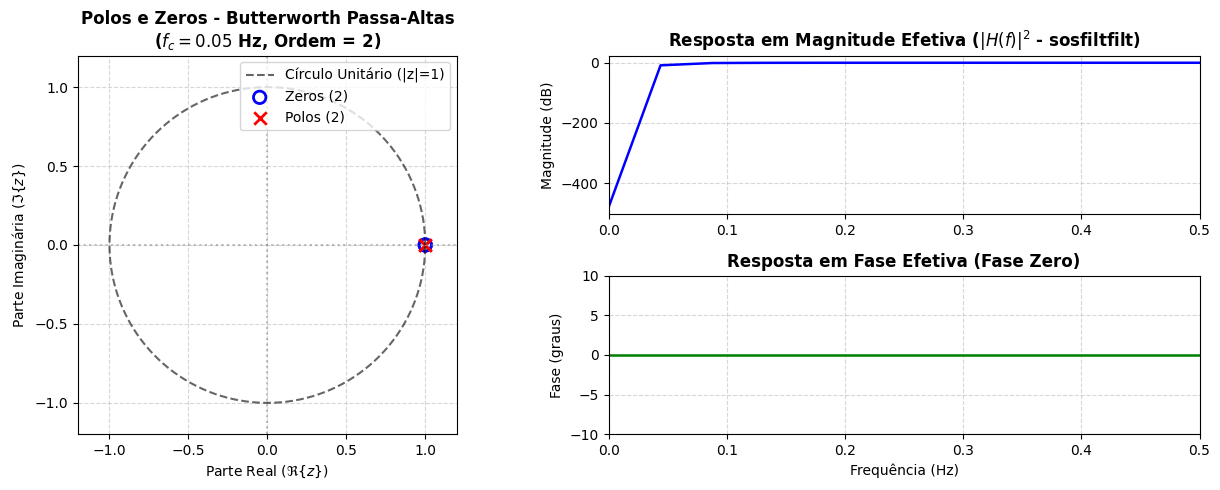

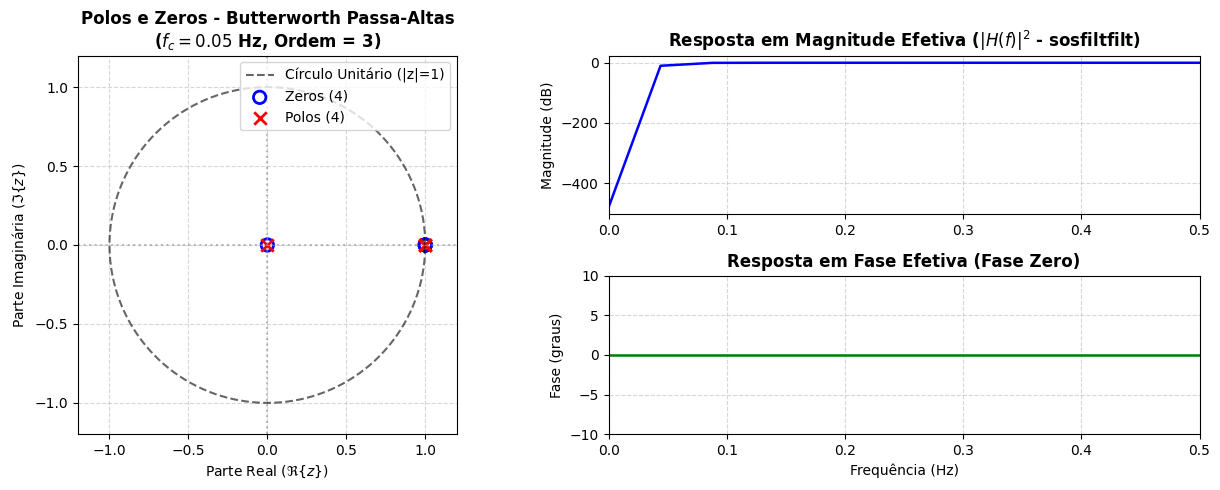

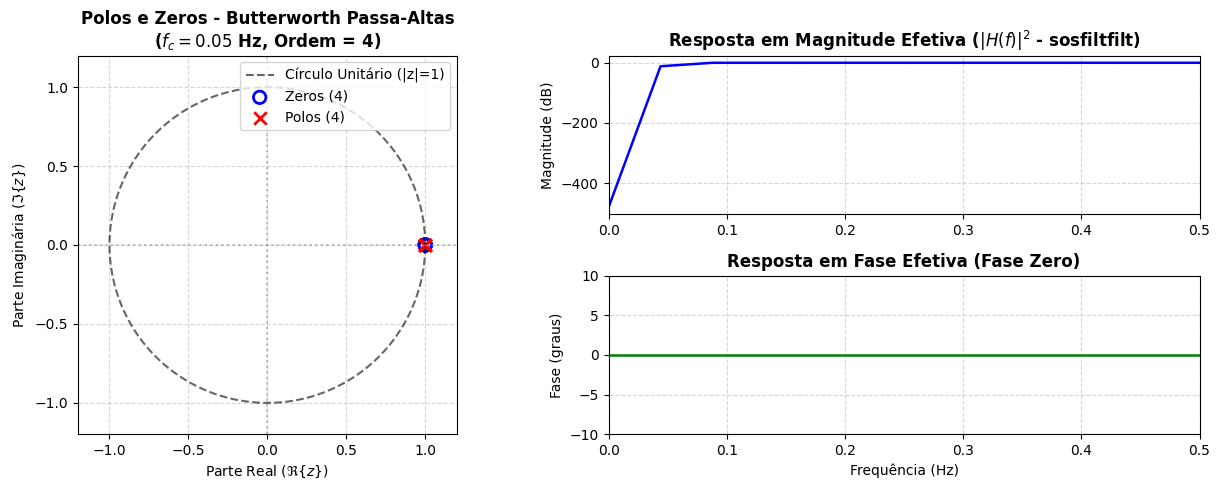

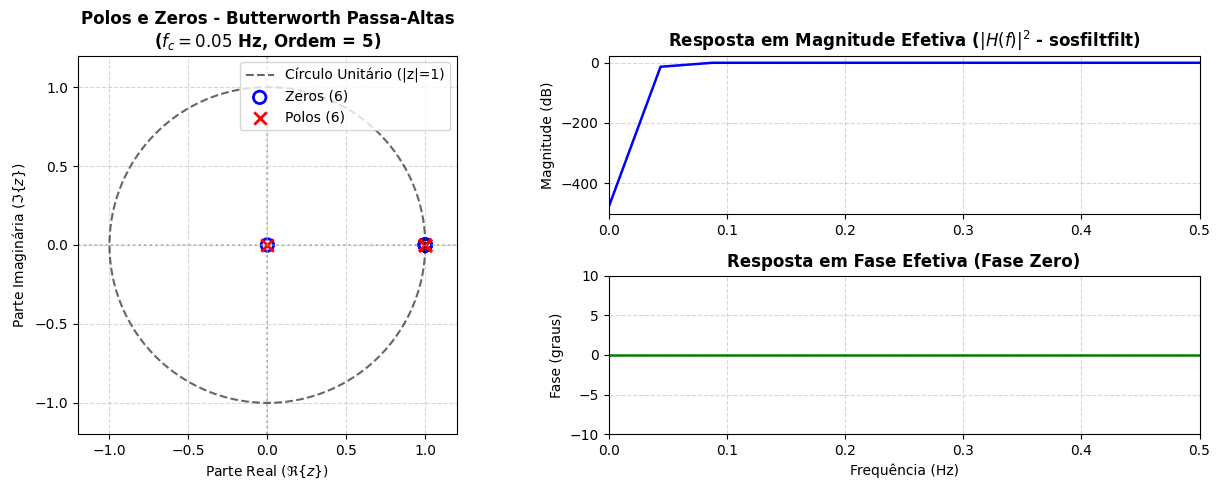

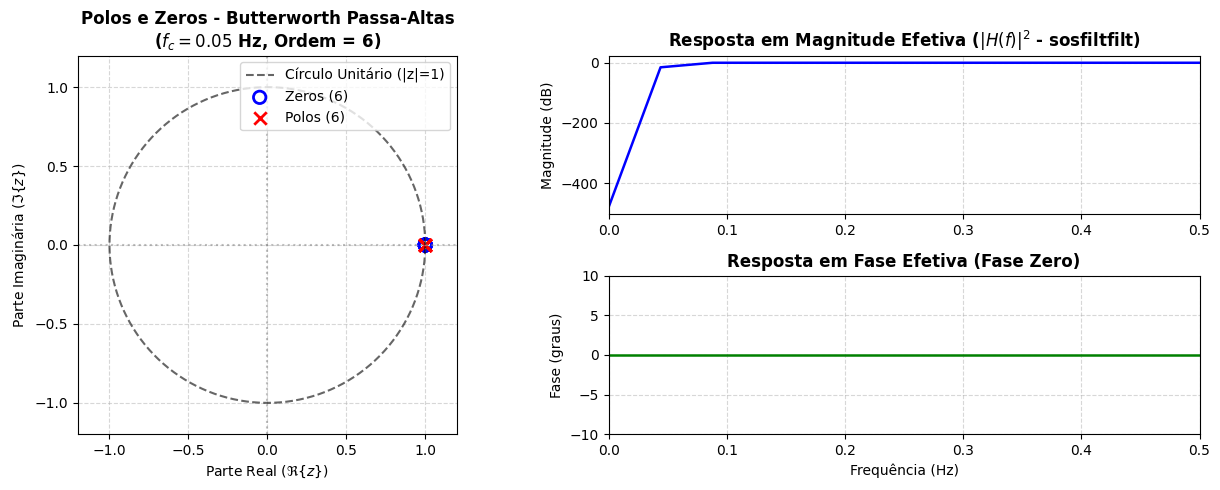

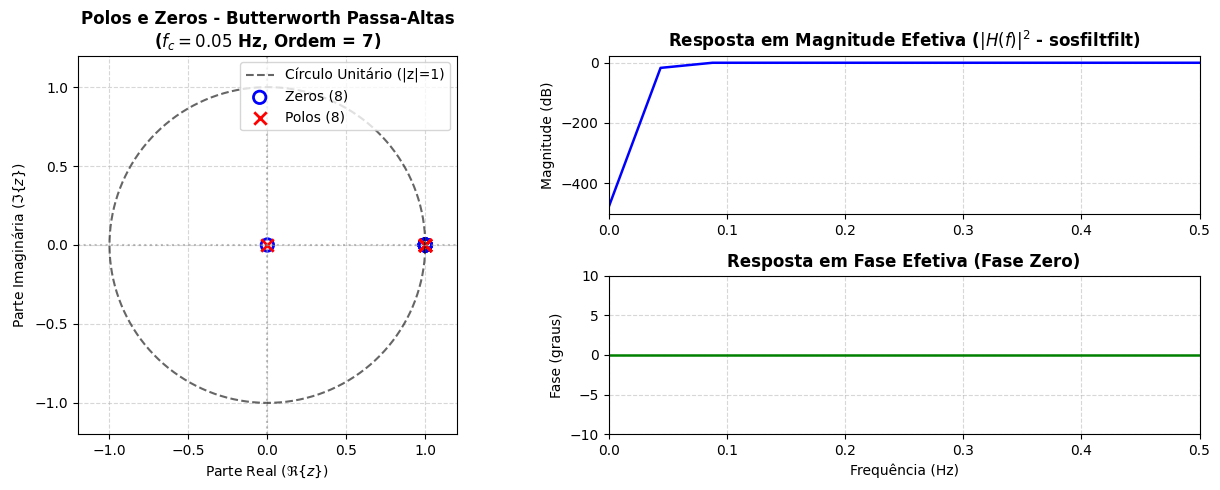

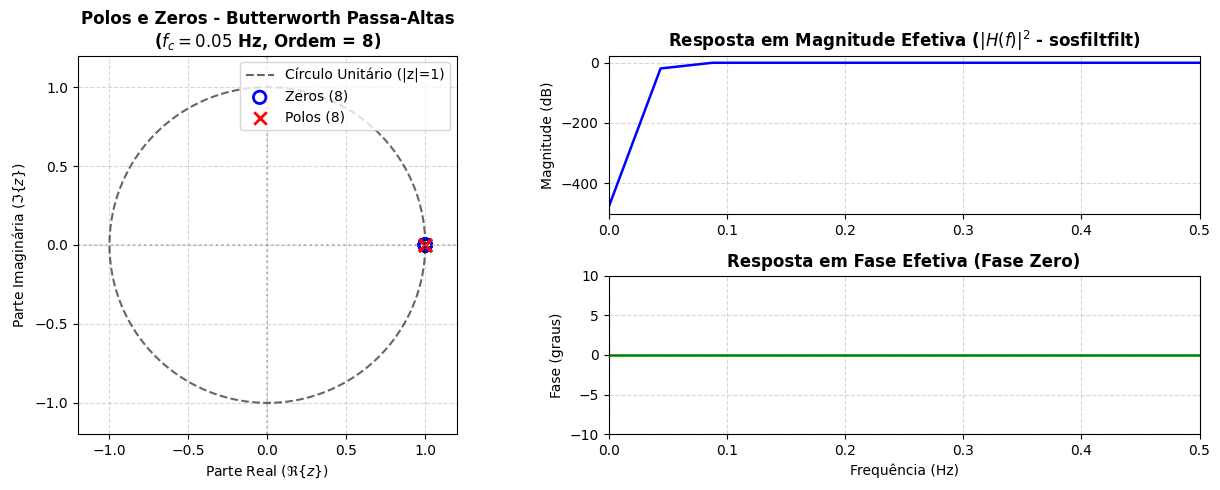

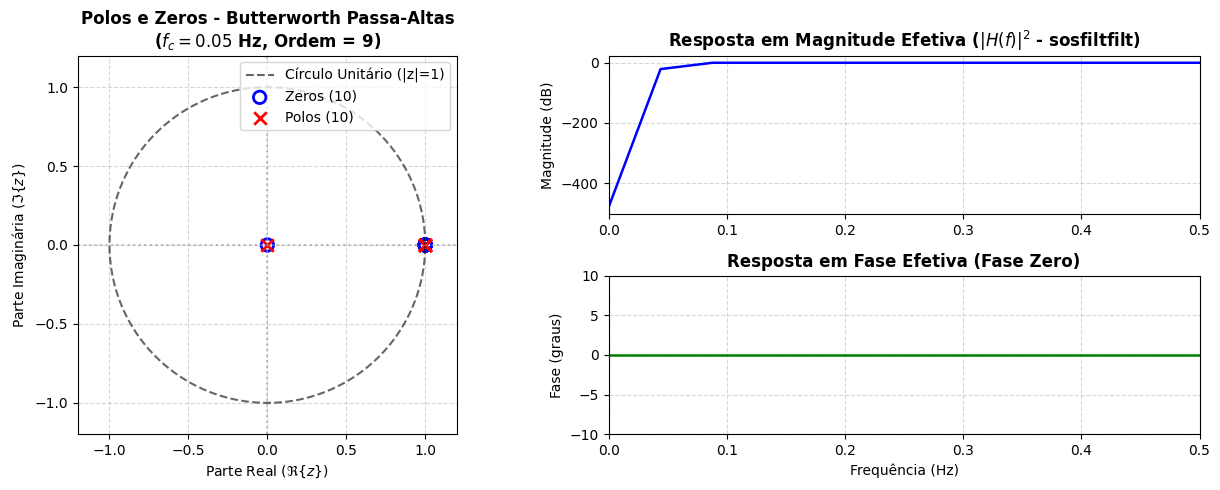

In [85]:
for i in range(1,10):
    analisar_butterworth_passa_alta(fs=360, freq_corte=0.05, ordem=i, xlim=(0, 0.5))


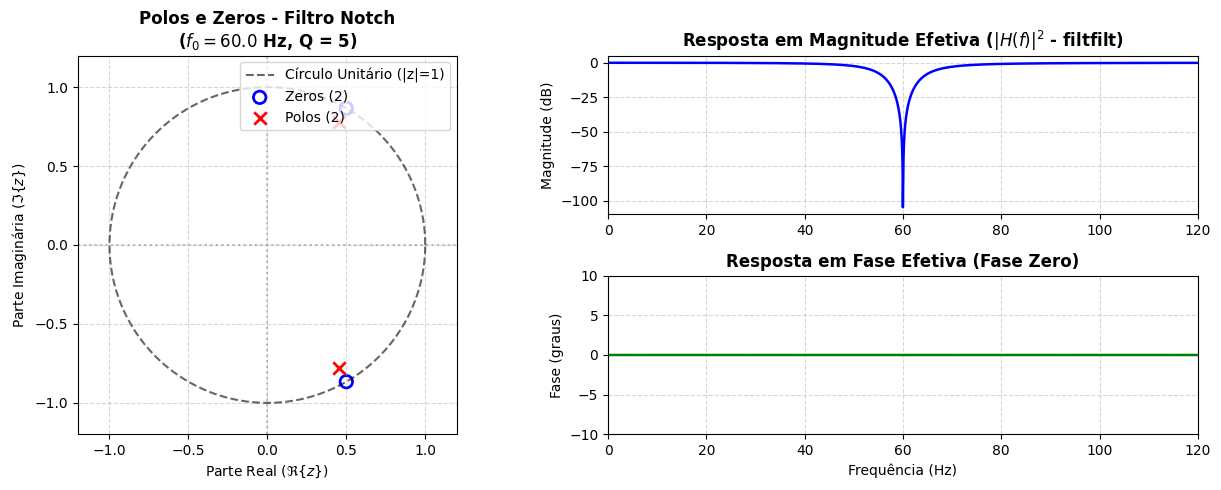

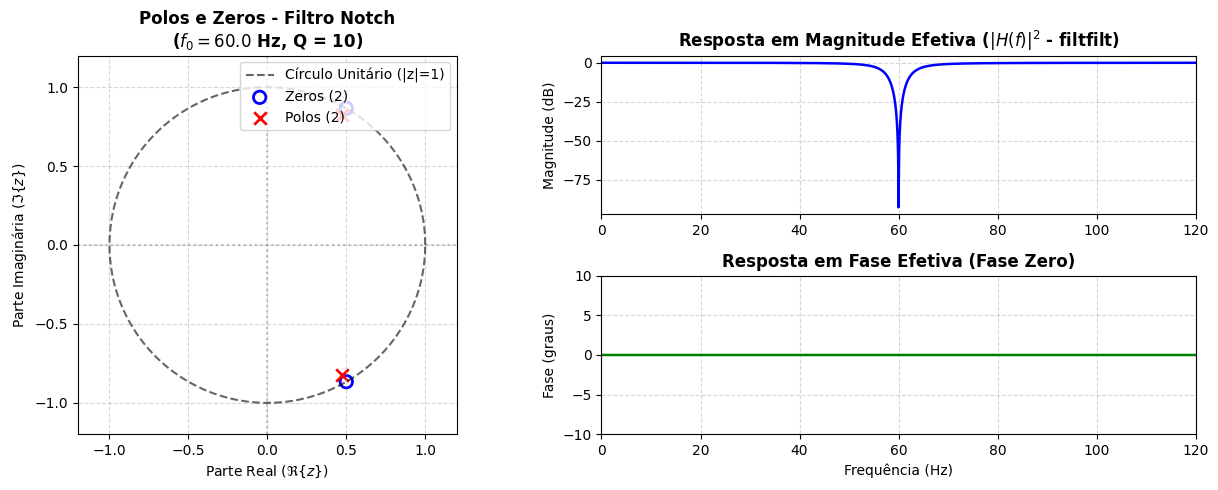

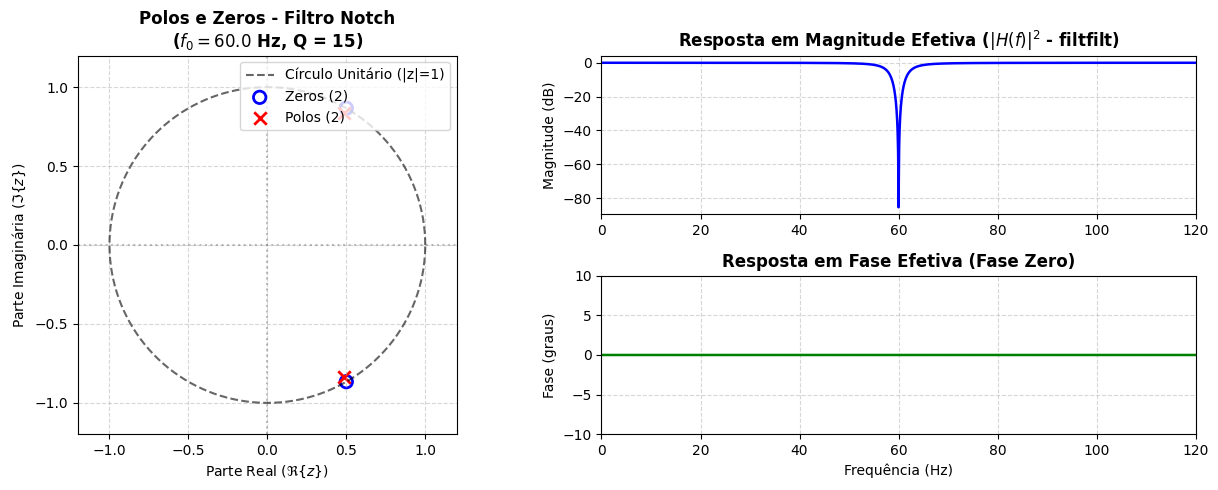

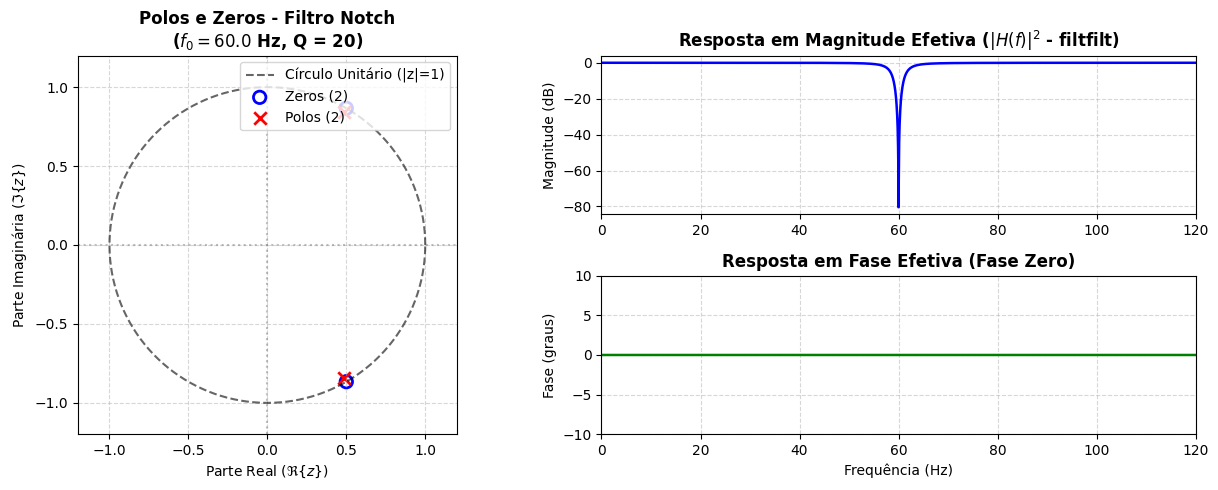

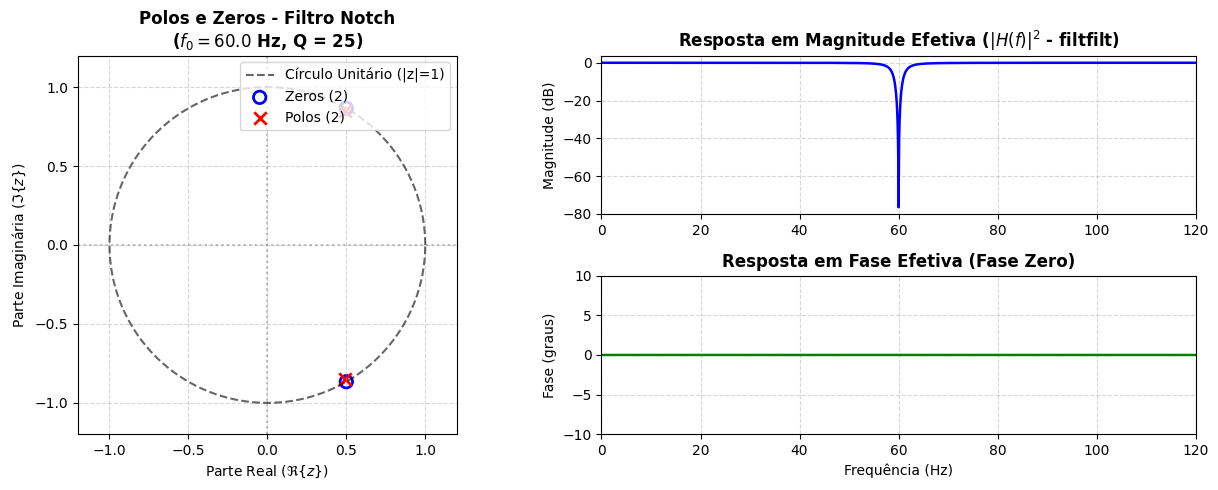

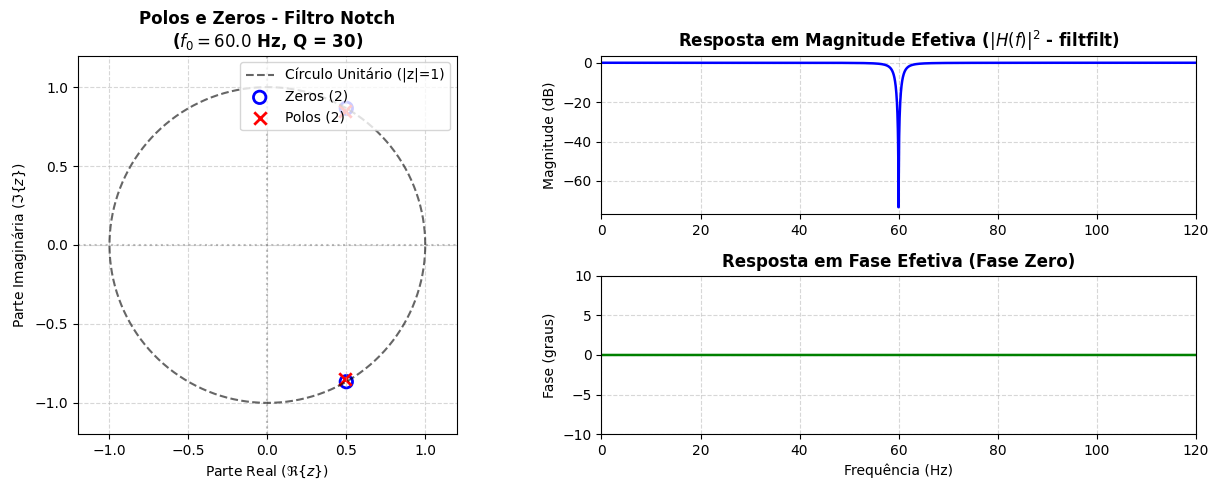

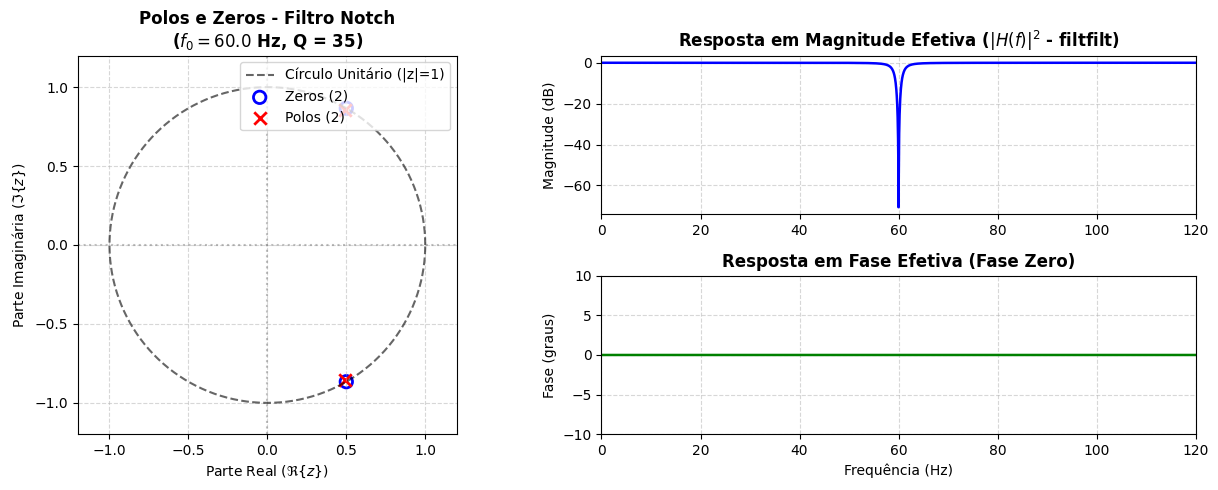

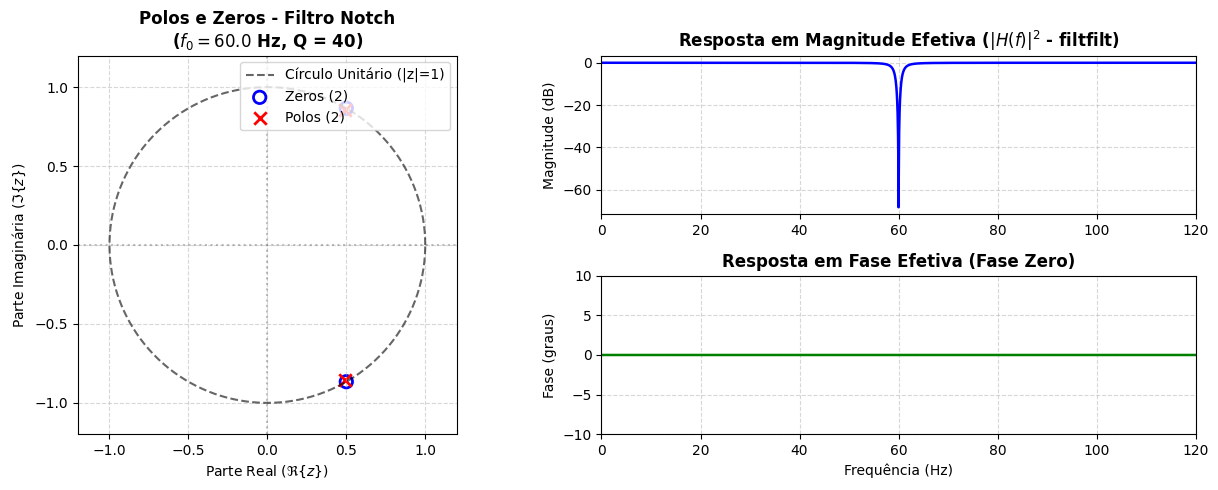

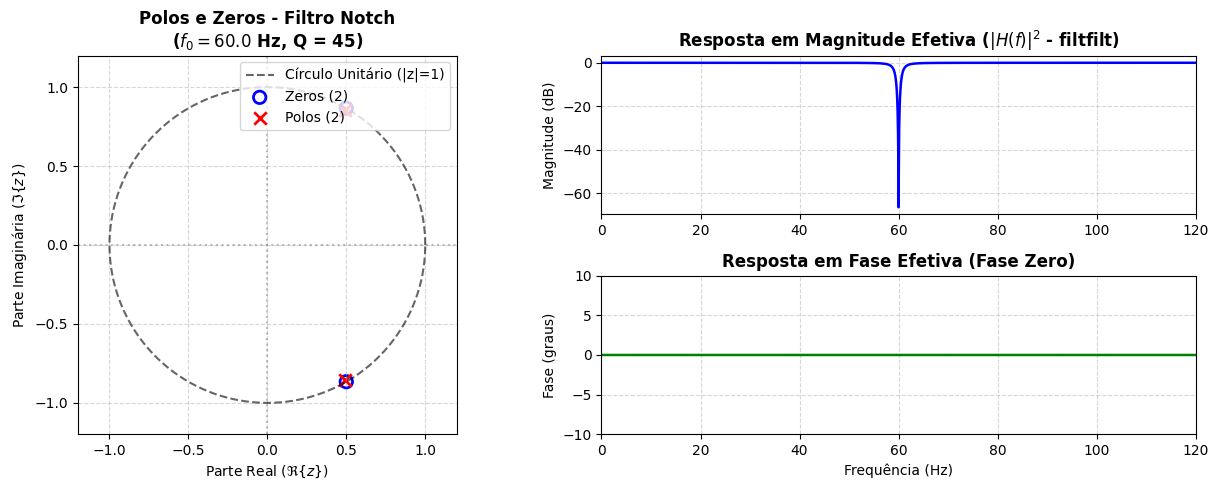

In [87]:
for i in range(1,10):
    Q = i*5
    analisar_filtro_notch(fs=360, freq_rejeicao=60.0, Q=Q, xlim=(0, 120))